## Loading Dataset

In [3]:
import json
import os
import pandas as pd
import random

# Load random subsection of the training dataset
dataset_path = "SemEval8_Dataset/subtaskA_train_monolingual.jsonl"
num_samples = 100  # Number of random samples to load

# Read all records first
all_records = []
with open(dataset_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            all_records.append(json.loads(line))

# Randomly sample num_samples records
records = random.sample(all_records, min(num_samples, len(all_records)))

# Convert to DataFrame for easier exploration
df = pd.DataFrame(records)
print(f"Loaded {len(df)} random records from training dataset")
print(f"\nDataframe shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few records:")
df.head()

Loaded 100 random records from training dataset

Dataframe shape: (100, 5)

Column names: ['text', 'label', 'model', 'source', 'id']

First few records:


,text,label,model,source,id
0,German destroyer Z28 The German destroyer Z28...,1,cohere,wikipedia,7972
1,Shake the cat bed to loosen the hair. You can...,0,human,wikihow,57423
2,The ability to record high-fidelity videos a...,0,human,arxiv,112881
3,Prepare as much as possible while the boat is...,0,human,wikihow,70535
4,"Martin Ellerby (1957, Worksop, Nottinghamshire...",0,human,wikipedia,82400


## Checking Dev/Valid dataset

In [4]:
# Load random subsection of the validation dataset
val_dataset_path = "SemEval8_Dataset/subtaskA_dev_monolingual.jsonl"
val_num_samples = 100  # Number of random samples to load

# Read all validation records first
all_val_records = []
with open(val_dataset_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            all_val_records.append(json.loads(line))

# Randomly sample val_num_samples records
val_records = random.sample(all_val_records, min(val_num_samples, len(all_val_records)))

# Convert to DataFrame for easier exploration
val_df = pd.DataFrame(val_records)
print(f"Loaded {len(val_df)} random records from validation dataset")
print(f"\nValidation dataframe shape: {val_df.shape}")
print(f"\nColumn names: {val_df.columns.tolist()}")
print(f"\nFirst few validation records:")
val_df.head()

Loaded 100 random records from validation dataset

Validation dataframe shape: (100, 5)

Column names: ['text', 'label', 'model', 'source', 'id']

First few validation records:


,text,label,model,source,id
0,"Claudine K. Brown (1949 – March 17, 2016) was ...",0,human,wikipedia,1701
1,"In Table 1, do the 4-layer SFNNs have one or t...",0,human,peerread,4767
2,"Daniel ""Dan"" T. Griswold (born 1958) is a seni...",0,human,wikipedia,1974
3,Netflix is more popular than other streaming s...,1,bloomz,reddit,2239
4,Sexto Sentido () is the fourteenth studio albu...,0,human,wikipedia,1598


## Statistical Dataset Analysis

### Distribution Analysis of Classes

C:\Users\OMNI BOOK\AppData\Local\Temp\ipykernel_22372\3570107363.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_counts, x=model_col, y='count', ax=ax, palette='deep')


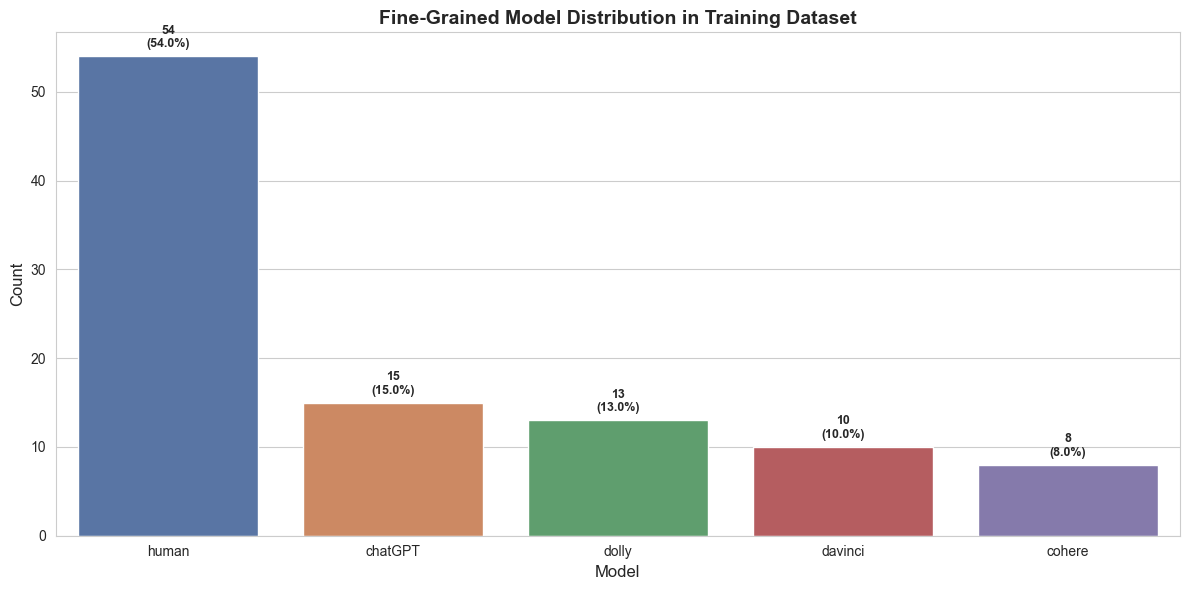

Model Distribution (Fine-Grained):
model
human      54
chatGPT    15
dolly      13
davinci    10
cohere      8
Name: count, dtype: int64

Percentages:
model
human      54.0
chatGPT    15.0
dolly      13.0
davinci    10.0
cohere      8.0
Name: count, dtype: float64


In [9]:
# Fine-grained analysis per model using seaborn
# Look for model information in the data
model_col = None
for col in df.columns:
    if 'model' in col.lower():
        model_col = col
        break

if model_col and model_col in df.columns and df[model_col].nunique() > 1:
    model_dist = df[model_col].value_counts()
    
    # Create detailed bar chart for each model using seaborn
    fig, ax = plt.subplots(figsize=(12, 6))
    model_counts = df[model_col].value_counts().reset_index()
    model_counts.columns = [model_col, 'count']
    
    sns.barplot(data=model_counts, x=model_col, y='count', ax=ax, palette='deep')
    ax.set_title('Fine-Grained Model Distribution in Training Dataset', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    
    # Add count and percentage labels on bars
    total = model_counts['count'].sum()
    for i, (idx, row) in enumerate(model_counts.iterrows()):
        pct = (row['count'] / total) * 100
        ax.text(i, row['count'] + 1, f"{row['count']}\n({pct:.1f}%)", 
                ha='center', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Model Distribution (Fine-Grained):\n{model_dist}")
    print(f"\nPercentages:\n{(model_dist / model_dist.sum() * 100).round(2)}")
else:
    print("Could not find model column with multiple model types")
    if model_col:
        print(f"Model column '{model_col}' has only {df[model_col].nunique()} unique value(s)")
    print(f"Available columns: {df.columns.tolist()}")

### Average Sentence Length

Running sentence length analysis 5 times with 5000 samples each...

Run 1/5:
  Analyzed 5000 sentences
  Mean: 468.5, Median: 277.0, Std: 682.4

Run 2/5:
  Analyzed 5000 sentences
  Mean: 447.9, Median: 277.0, Std: 622.4

Run 3/5:
  Analyzed 5000 sentences
  Mean: 452.5, Median: 276.0, Std: 593.7

Run 4/5:
  Analyzed 5000 sentences
  Mean: 466.4, Median: 275.0, Std: 687.0

Run 5/5:
  Analyzed 5000 sentences
  Mean: 462.3, Median: 278.0, Std: 631.8

AVERAGE STATISTICS ACROSS ALL RUNS
Sentence Length Statistics (words) - Averaged over 5 runs:
  Min: 12.8
  Max: 15649.2
  Mean: 459.5
  Median: 276.6
  Standard Deviation: 643.5


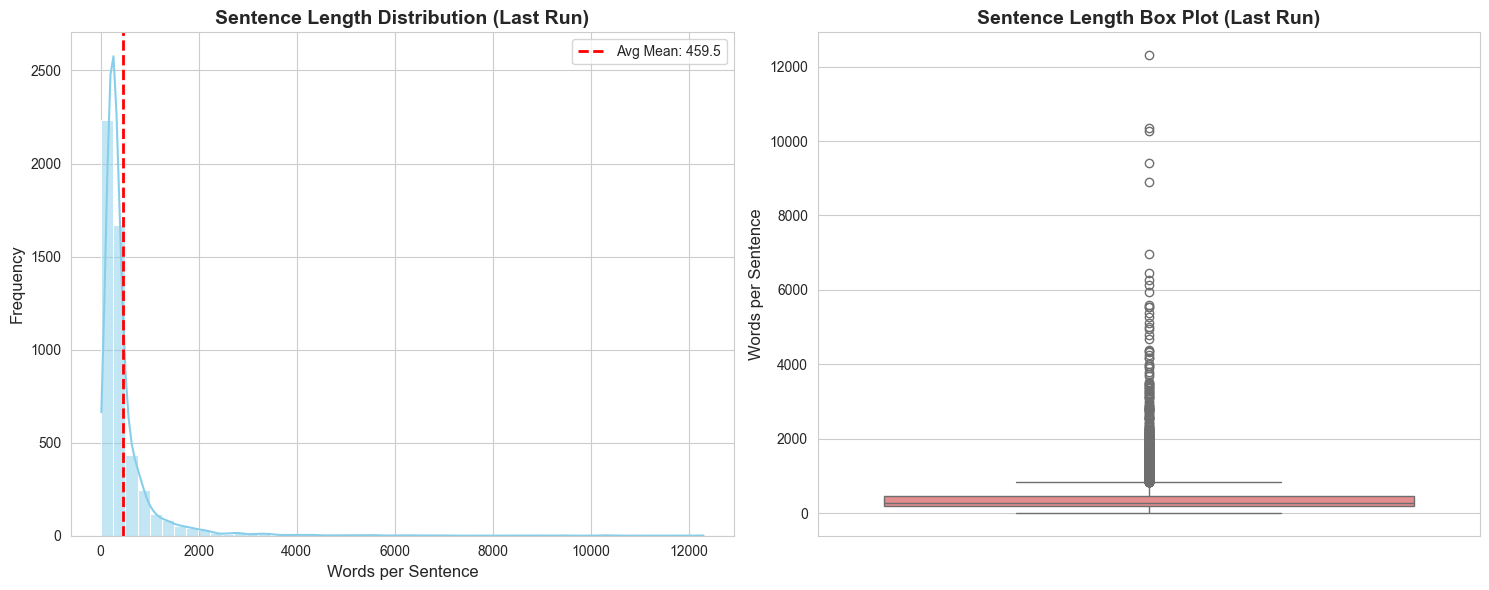


Variability across runs:
  Mean sentence lengths: [468.4712, 447.9144, 452.5446, 466.389, 462.3066]
  Range of means: 447.9 - 468.5
  Standard deviation of means: 8.922


In [14]:
import statistics

# Analyze sentence lengths from multiple random subsamples for more robust statistics
num_runs = 5
subsample_size = 5000  # Adjust this number based on your needs

# Store statistics from each run
all_stats = []

print(f"Running sentence length analysis {num_runs} times with {subsample_size} samples each...")

for run in range(num_runs):
    print(f"\nRun {run + 1}/{num_runs}:")

    # Get a different random subsample each time
    subsample = random.sample(all_records, min(subsample_size, len(all_records)))

    # Extract text and calculate lengths
    sentence_lengths = []
    for record in subsample:
        # Try different possible text field names
        text = ""
        if 'text' in record:
            text = record['text']

        if text:
            # Split by spaces to get word count (sentence length)
            word_count = len(text.split())
            sentence_lengths.append(word_count)

    if sentence_lengths:
        # Calculate statistics for this run
        run_stats = {
            'min': min(sentence_lengths),
            'max': max(sentence_lengths),
            'mean': statistics.mean(sentence_lengths),
            'median': statistics.median(sentence_lengths),
            'std': statistics.stdev(sentence_lengths),
            'count': len(sentence_lengths)
        }

        all_stats.append(run_stats)

        print(f"  Analyzed {len(sentence_lengths)} sentences")
        print(f"  Mean: {run_stats['mean']:.1f}, Median: {run_stats['median']:.1f}, Std: {run_stats['std']:.1f}")
    else:
        print("  No text data found in this subsample")

# Calculate average statistics across all runs
if all_stats:
    print(f"\n{'='*60}")
    print("AVERAGE STATISTICS ACROSS ALL RUNS")
    print(f"{'='*60}")

    avg_stats = {
        'min': statistics.mean([s['min'] for s in all_stats]),
        'max': statistics.mean([s['max'] for s in all_stats]),
        'mean': statistics.mean([s['mean'] for s in all_stats]),
        'median': statistics.mean([s['median'] for s in all_stats]),
        'std': statistics.mean([s['std'] for s in all_stats])
    }

    print(f"Sentence Length Statistics (words) - Averaged over {num_runs} runs:")
    print(f"  Min: {avg_stats['min']:.1f}")
    print(f"  Max: {avg_stats['max']:.1f}")
    print(f"  Mean: {avg_stats['mean']:.1f}")
    print(f"  Median: {avg_stats['median']:.1f}")
    print(f"  Standard Deviation: {avg_stats['std']:.1f}")

    # Use the last run's data for visualization (or could average distributions)
    last_sentence_lengths = sentence_lengths

    # Create distribution plot using data from the last run
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Histogram
    sns.histplot(last_sentence_lengths, bins=50, kde=True, ax=ax1, color='skyblue')
    ax1.set_title('Sentence Length Distribution (Last Run)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Words per Sentence', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.axvline(avg_stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Avg Mean: {avg_stats["mean"]:.1f}')
    ax1.legend()

    # Box plot
    sns.boxplot(y=last_sentence_lengths, ax=ax2, color='lightcoral')
    ax2.set_title('Sentence Length Box Plot (Last Run)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Words per Sentence', fontsize=12)

    plt.tight_layout()
    plt.show()

    # Show variability across runs
    print(f"\nVariability across runs:")
    means = [s['mean'] for s in all_stats]
    print(f"  Mean sentence lengths: {means}")
    print(f"  Range of means: {min(means):.1f} - {max(means):.1f}")
    print(f"  Standard deviation of means: {statistics.stdev(means):.3f}")

else:
    print("No text data found in any subsample")